In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('/content/Coffee Shop Sales.xlsx')
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [5]:
#cek missing values
missing_values = df.isnull().sum()
print (missing_values)

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


In [6]:
#melihat tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [10]:
#mengubah transaction_time ke tipe string
df['transaction_time'] = df['transaction_time'].astype(str)
df['transaction_time'] = pd.to_timedelta(df['transaction_time'])

In [11]:
df['sales'] = df['transaction_qty']*df['unit_price']

In [16]:
df['datetime'] = df['transaction_date']+df['transaction_time']

In [17]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,sales,datime,dateime,datetime
0,1,2023-01-01,0 days 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2023-01-01 07:06:11,2023-01-01 07:06:11,2023-01-01 07:06:11
1,2,2023-01-01,0 days 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023-01-01 07:08:56,2023-01-01 07:08:56,2023-01-01 07:08:56
2,3,2023-01-01,0 days 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,2023-01-01 07:14:04,2023-01-01 07:14:04,2023-01-01 07:14:04
3,4,2023-01-01,0 days 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2023-01-01 07:20:24,2023-01-01 07:20:24,2023-01-01 07:20:24
4,5,2023-01-01,0 days 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023-01-01 07:22:41,2023-01-01 07:22:41,2023-01-01 07:22:41


In [19]:
#kelompokan data berdasarkan lokasi toko dan analisis pejualan dan number of traansaction
df_location = df.groupby('store_location').agg({
    'sales':'sum',
    'transaction_id':'count'
})
df_location

,sales,transaction_id
store_location,,
Astoria,232243.91,50599
Hell's Kitchen,236511.17,50735
Lower Manhattan,230057.25,47782


In [20]:
#grafik garis dari location dan day
daily_sales_by_location = df.groupby(['transaction_date','store_location'])['sales'].sum().unstack()
daily_sales_by_location

store_location,Astoria,Hell's Kitchen,Lower Manhattan
transaction_date,,,
2023-01-01,868.40,851.45,788.35
2023-01-02,925.50,828.80,649.05
2023-01-03,902.75,906.25,756.00
2023-01-04,808.25,781.65,630.20
2023-01-05,903.05,714.90,800.90
...,...,...,...
2023-06-26,1975.10,1746.10,2154.70
2023-06-27,1861.55,1676.70,2437.40
2023-06-28,1758.10,1445.85,1524.95


In [21]:
test = df.groupby(['transaction_date','store_location'])['sales'].sum()
test

transaction_date  store_location 
2023-01-01        Astoria             868.40
                  Hell's Kitchen      851.45
                  Lower Manhattan     788.35
2023-01-02        Astoria             925.50
                  Hell's Kitchen      828.80
                                      ...   
2023-06-29        Hell's Kitchen     1298.55
                  Lower Manhattan    1299.45
2023-06-30        Astoria            1807.65
                  Hell's Kitchen     1904.93
                  Lower Manhattan    1768.74
Name: sales, Length: 543, dtype: float64

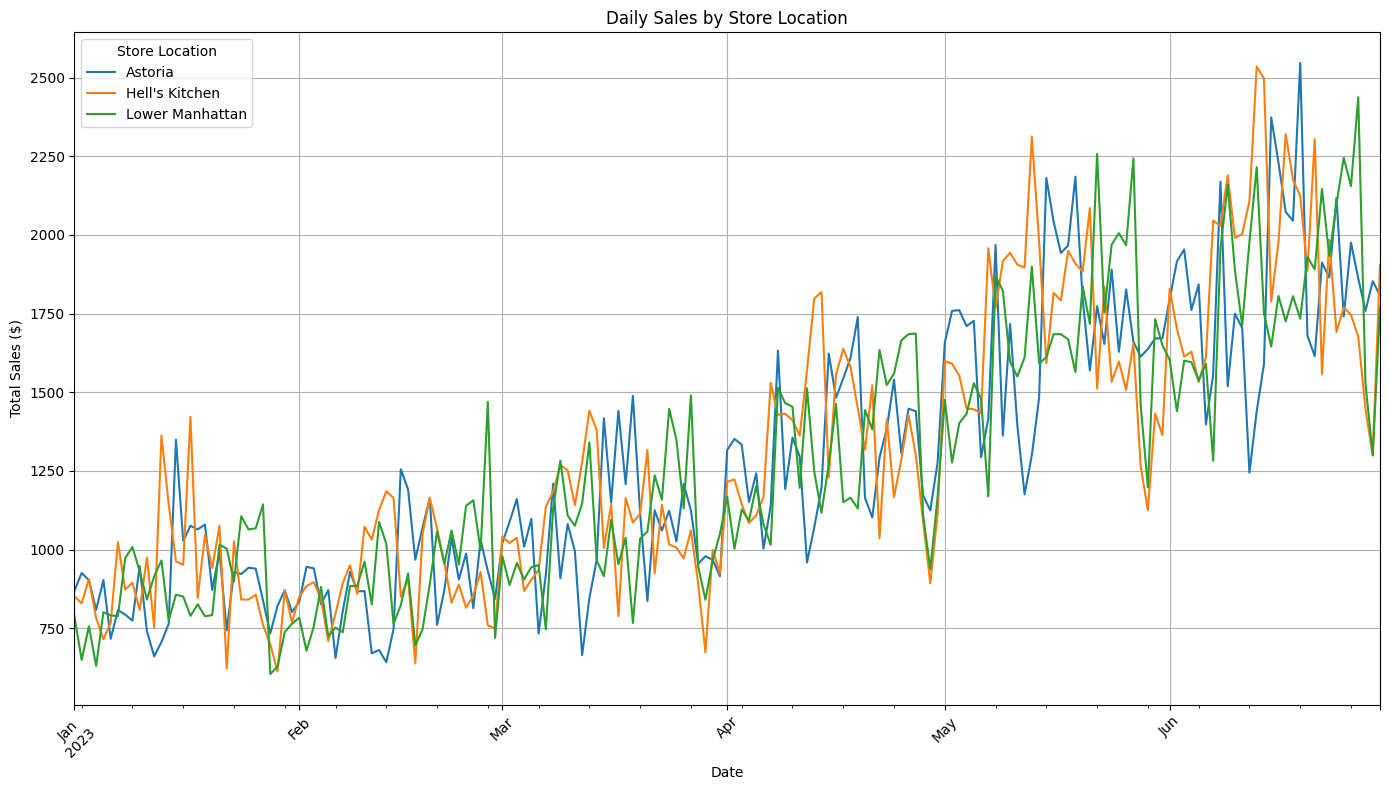

In [23]:
daily_sales_by_location.plot(
    figsize=(14, 8),
    title='Daily Sales by Store Location')

plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend(title='Store Location')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Tampilkan plot
plt.show()

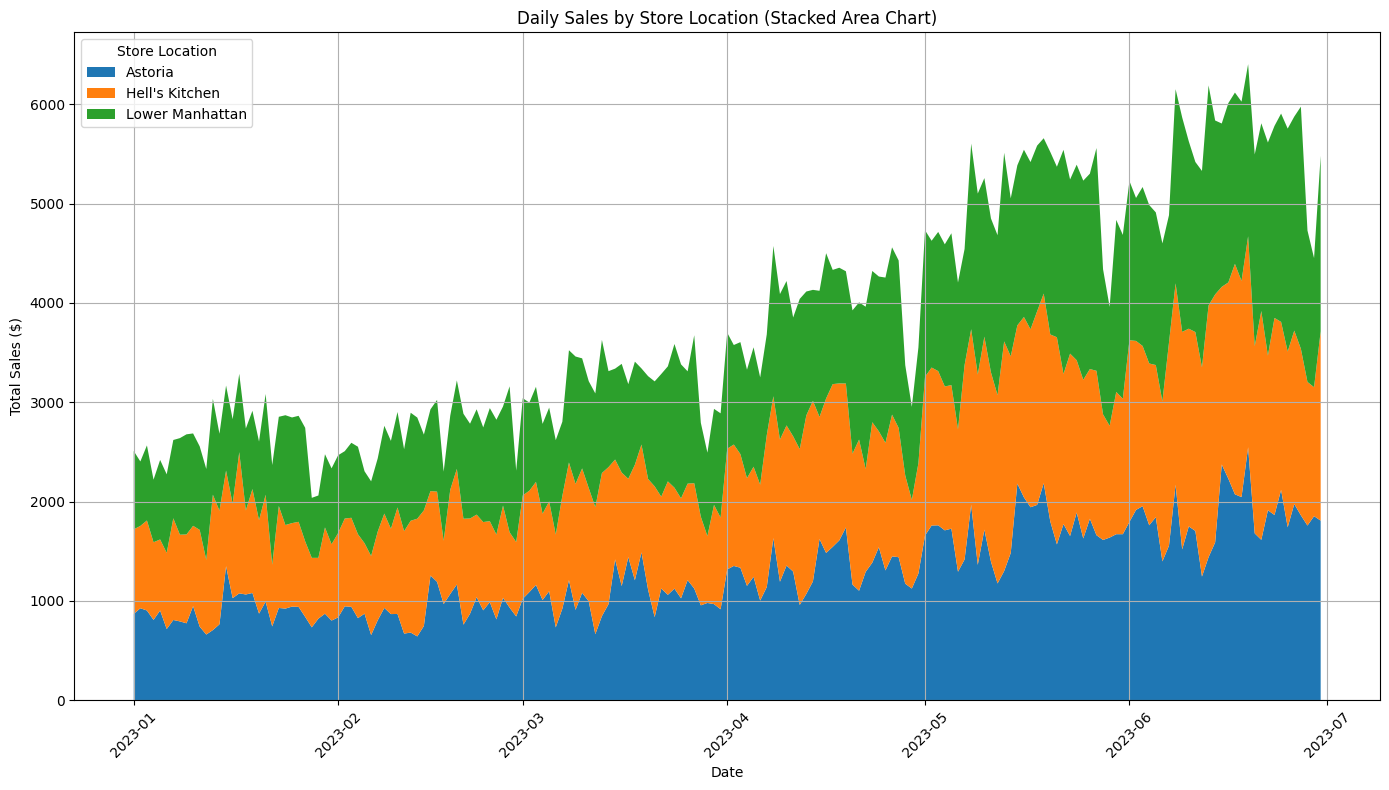

In [24]:
plt.figure(figsize=(14, 8))

plt.stackplot(daily_sales_by_location.index, daily_sales_by_location.T, labels=daily_sales_by_location.columns)

plt.title('Daily Sales by Store Location (Stacked Area Chart)')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend(title='Store Location', loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Tampilkan plot
plt.show()

In [29]:
daily_sales = df.groupby('transaction_date')['sales'].sum().reset_index()

df['day_of_week'] = df['datetime'].dt.day_name()

weekly_sales = (
    df.groupby('day_of_week')['sales']
      .sum()
      .reindex([
          'Monday',
          'Tuesday',
          'Wednesday',
          'Thursday',
          'Friday',
          'Saturday',
          'Sunday'
      ])
      .reset_index()
)

df['month'] = df['datetime'].dt.to_period('M')
monthly_sales = df.groupby('month')['sales'].sum().reset_index()

daily_sales, weekly_sales, monthly_sales

(    transaction_date    sales
 0         2023-01-01  2508.20
 1         2023-01-02  2403.35
 2         2023-01-03  2565.00
 3         2023-01-04  2220.10
 4         2023-01-05  2418.85
 ..               ...      ...
 176       2023-06-26  5875.90
 177       2023-06-27  5975.65
 178       2023-06-28  4728.90
 179       2023-06-29  4450.75
 180       2023-06-30  5481.32
 
 [181 rows x 2 columns],
   day_of_week      sales
 0      Monday  101677.28
 1     Tuesday   99455.94
 2   Wednesday  100313.54
 3    Thursday  100767.78
 4      Friday  101373.00
 5    Saturday   96894.48
 6      Sunday   98330.31,
      month      sales
 0  2023-01   81677.74
 1  2023-02   76145.19
 2  2023-03   98834.68
 3  2023-04  118941.08
 4  2023-05  156727.76
 5  2023-06  166485.88)

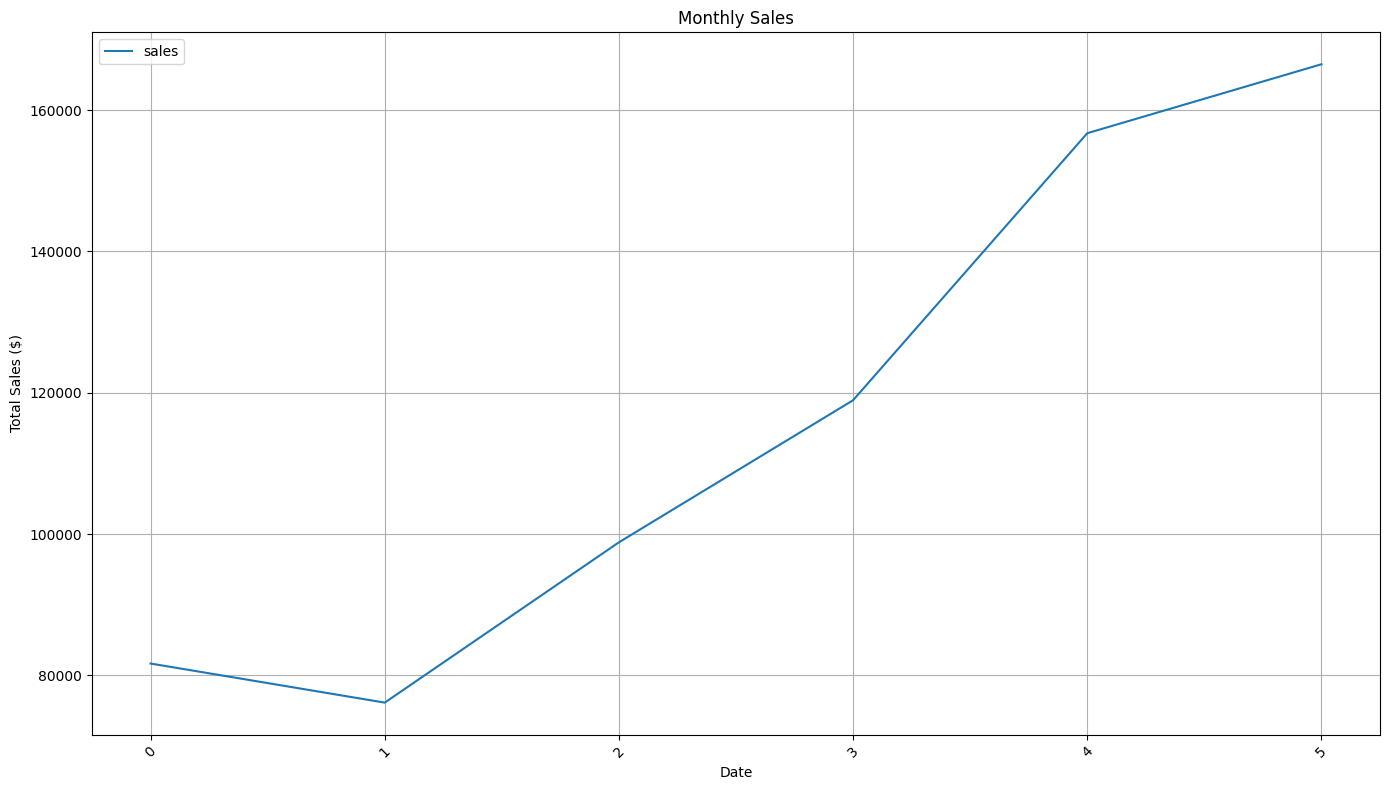

In [30]:
monthly_sales.plot(
    figsize=(14, 8),
    title='Monthly Sales')

plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Tampilkan plot
plt.show()

In [32]:
weekly_sales = df.groupby(['day_of_week', 'store_location'])['sales'].sum().unstack()

days_order = ['Monday',
          'Tuesday',
          'Wednesday',
          'Thursday',
          'Friday',
          'Saturday',
          'Sunday']
weekly_sales = weekly_sales.reindex(days_order)
weekly_sales

store_location,Astoria,Hell's Kitchen,Lower Manhattan
day_of_week,,,
Monday,33928.29,33389.51,34359.48
Tuesday,31816.76,34846.47,32792.71
Wednesday,34244.63,33779.09,32289.82
Thursday,34140.37,33468.06,33159.35
Friday,33472.75,34743.18,33157.07
Saturday,31845.93,32599.23,32449.32
Sunday,32795.18,33685.63,31849.50


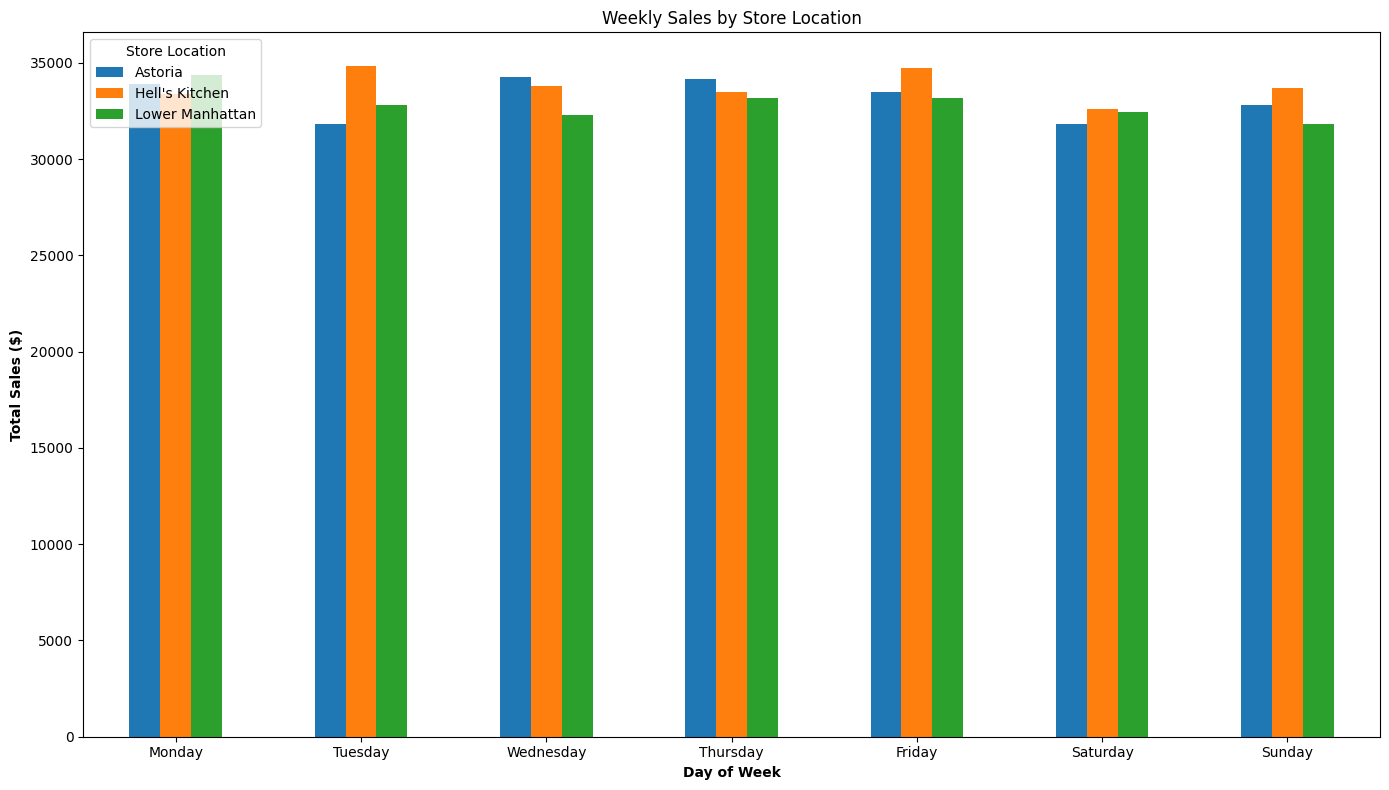

In [36]:
weekly_sales[["Astoria", "Hell's Kitchen", "Lower Manhattan"]].plot(
    kind='bar',
    figsize=(14, 8)
)

plt.xlabel('Day of Week', fontweight='bold')
plt.ylabel('Total Sales ($)', fontweight='bold')
plt.title('Weekly Sales by Store Location')
plt.legend(title='Store Location', loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

# Tampilkan plot
plt.show()

In [38]:
df_category = df.groupby('product_category').agg({
    'sales' : 'sum',
    'transaction_id' : 'count'
}).sort_values('sales', ascending= False)

df_category

,sales,transaction_id
product_category,,
Coffee,269952.45,58416
Tea,196405.95,45449
Bakery,82315.64,22796
Drinking Chocolate,72416.00,11468
Coffee beans,40085.25,1753
Branded,13607.00,747
Loose Tea,11213.60,1210
Flavours,8408.80,6790
Packaged Chocolate,4407.64,487


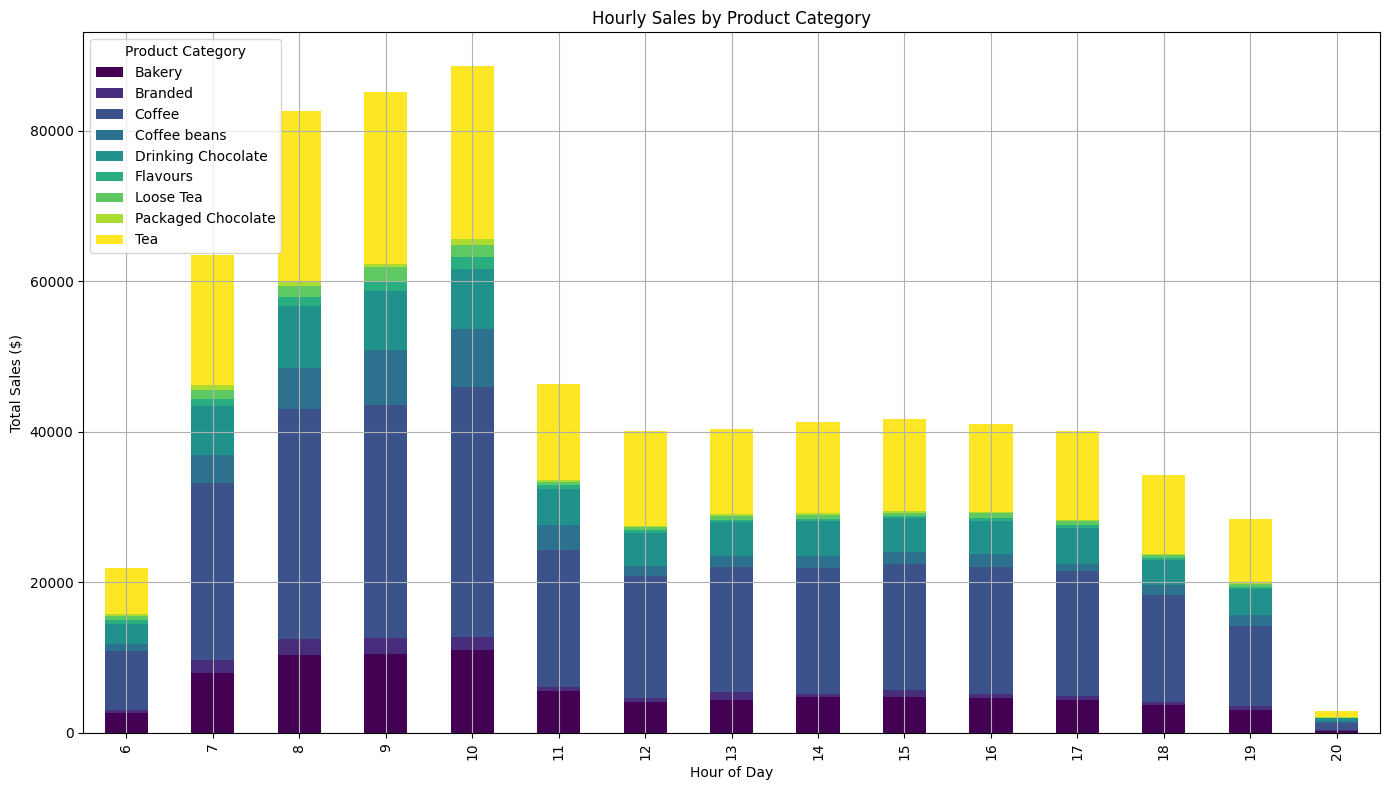

In [40]:
df['hour'] = df['datetime'].dt.hour

hourly_sales_by_product = (
    df.groupby(['hour', 'product_category'])['sales']
      .sum()
      .unstack()
)

hourly_sales_by_product.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    colormap='viridis'
)

plt.title('Hourly Sales by Product Category')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales ($)')
plt.legend(title='Product Category', loc='upper left')
plt.grid(True)
plt.tight_layout()

# Tampilkan plot
plt.show()

In [41]:
df_category['avg_sales'] = df_category['sales']/df_category['transaction_id']
df_category

,sales,transaction_id,avg_sales
product_category,,,
Coffee,269952.45,58416,4.621207
Tea,196405.95,45449,4.321458
Bakery,82315.64,22796,3.610969
Drinking Chocolate,72416.00,11468,6.314615
Coffee beans,40085.25,1753,22.866657
Branded,13607.00,747,18.215529
Loose Tea,11213.60,1210,9.267438
Flavours,8408.80,6790,1.238409
Packaged Chocolate,4407.64,487,9.050595


In [43]:
sales_by_product = df.groupby('product_type').agg({
    'sales' : 'sum',
    'unit_price' : 'mean'
}).sort_values('sales', ascending= False)

sales_by_product

,sales,unit_price
product_type,,
Barista Espresso,91406.20,3.655200
Brewed Chai tea,77081.95,2.936993
Hot chocolate,72416.00,4.148827
Gourmet brewed coffee,70034.60,2.696641
Brewed Black tea,47932.00,2.744670
Brewed herbal tea,47539.50,2.744731
Premium brewed coffee,38781.15,3.122452
Organic brewed coffee,37746.50,2.898021
Scone,36866.12,3.534638


In [47]:
product_sales_df = df.groupby(['product_category', 'product_type'])['sales'].sum().reset_index()
product_sales_df

,product_category,product_type,sales
0,Bakery,Biscotti,19793.53
1,Bakery,Pastry,25655.99
2,Bakery,Scone,36866.12
3,Branded,Clothing,6163.00
4,Branded,Housewares,7444.00
5,Coffee,Barista Espresso,91406.20
6,Coffee,Drip coffee,31984.00
7,Coffee,Gourmet brewed coffee,70034.60
8,Coffee,Organic brewed coffee,37746.50
9,Coffee,Premium brewed coffee,38781.15


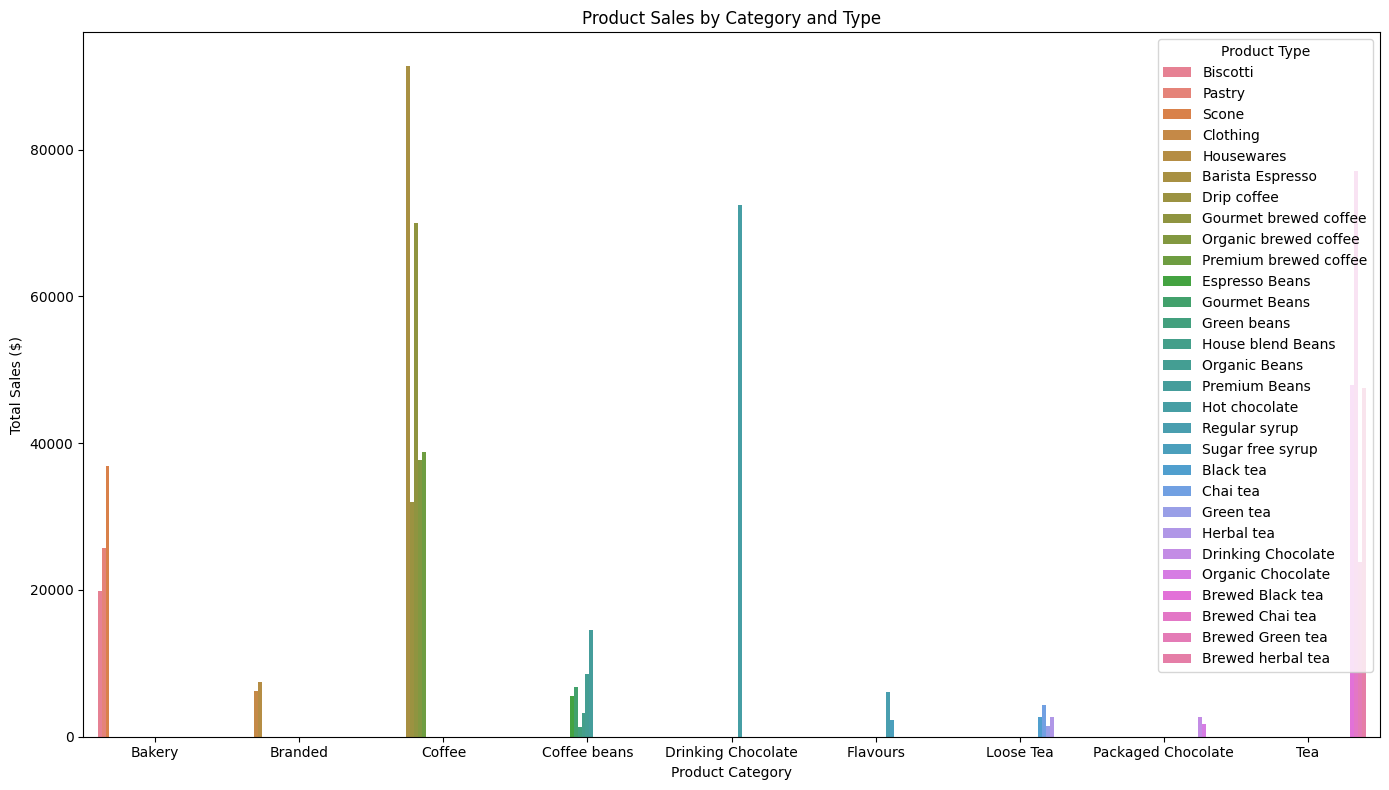

In [52]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=product_sales_df,
    x='product_category',
    y='sales',
    hue='product_type'
)

# Tambahkan label dan judul
plt.title('Product Sales by Category and Type')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.legend(title='Product Type', loc='upper right')

# Tampilkan plot
plt.tight_layout()
plt.show()

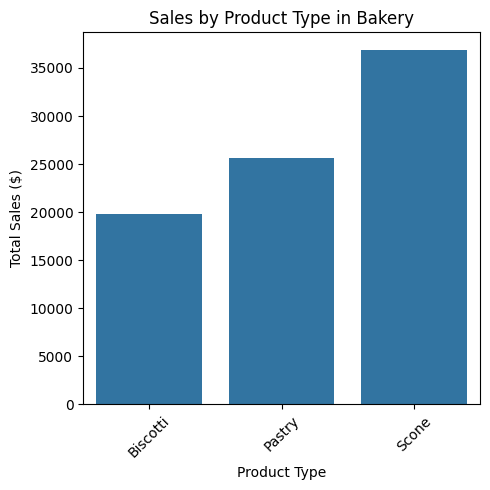

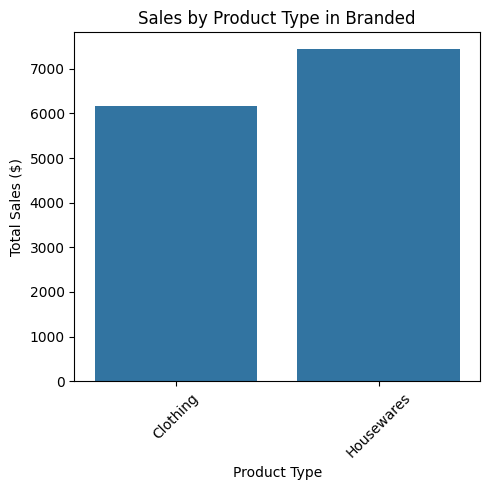

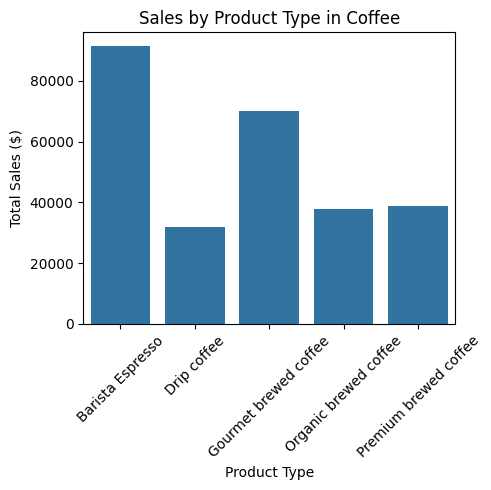

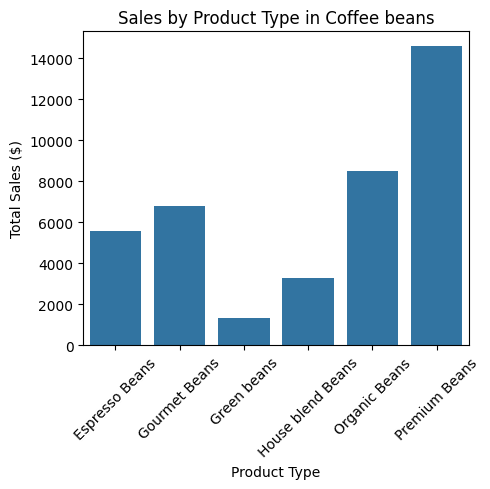

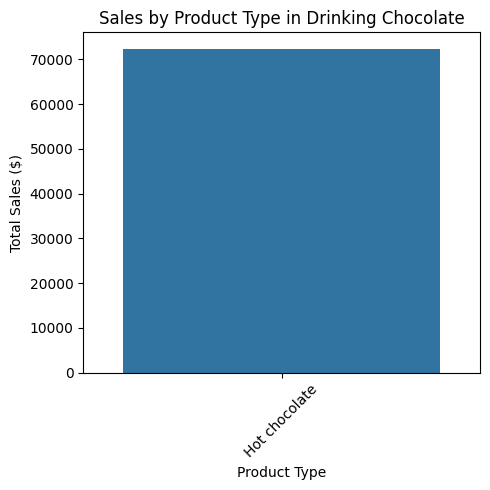

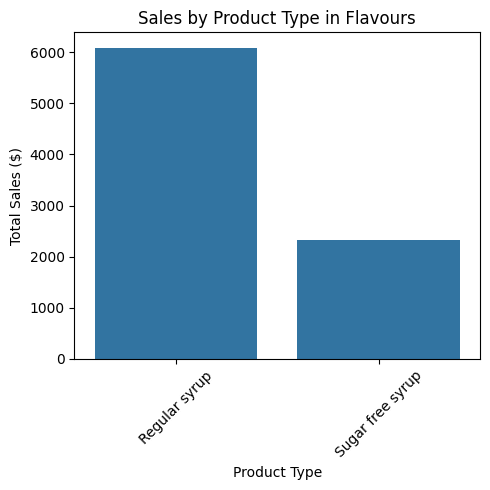

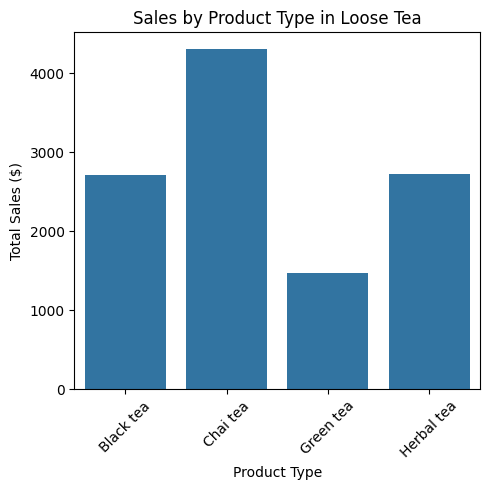

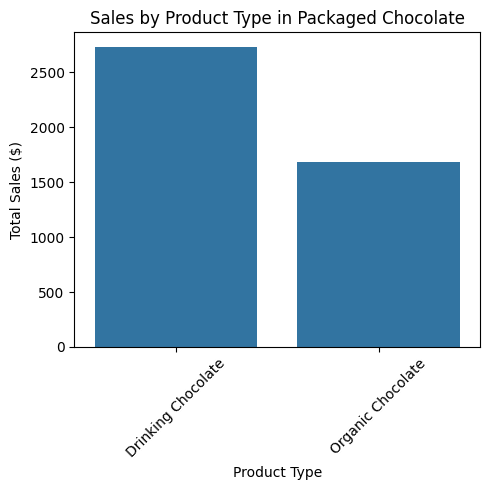

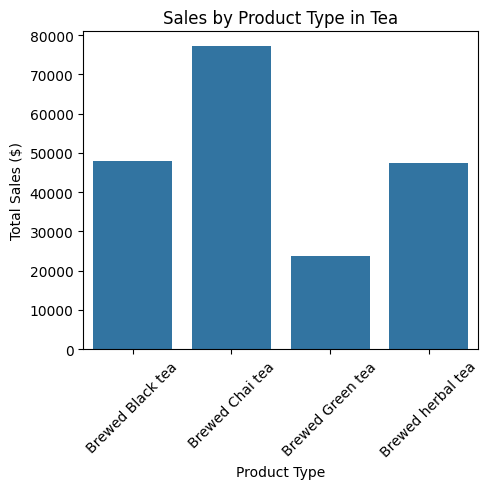

In [54]:
categories = product_sales_df['product_category'].unique()

for category in categories:
    plt.figure(figsize=(5, 5))

    category_data = product_sales_df[
        product_sales_df['product_category'] == category
    ]

    sns.barplot(
        data=category_data,
        x='product_type',
        y='sales'
    )

    # Tambahkan label dan judul
    plt.title(f'Sales by Product Type in {category}')
    plt.xlabel('Product Type')
    plt.ylabel('Total Sales ($)')
    plt.xticks(rotation=45)

    # Tampilkan plot
    plt.tight_layout()
    plt.show()

In [56]:
hourly_sales_by_location = df.groupby(['store_location', 'hour'])['sales'].sum().reset_index()
hourly_sales_by_location

,store_location,hour,sales
0,Astoria,7,19028.80
1,Astoria,8,22805.90
2,Astoria,9,23183.57
3,Astoria,10,24426.12
4,Astoria,11,15498.13
5,Astoria,12,15681.20
6,Astoria,13,15947.87
7,Astoria,14,15175.27
8,Astoria,15,15651.95
9,Astoria,16,16110.85


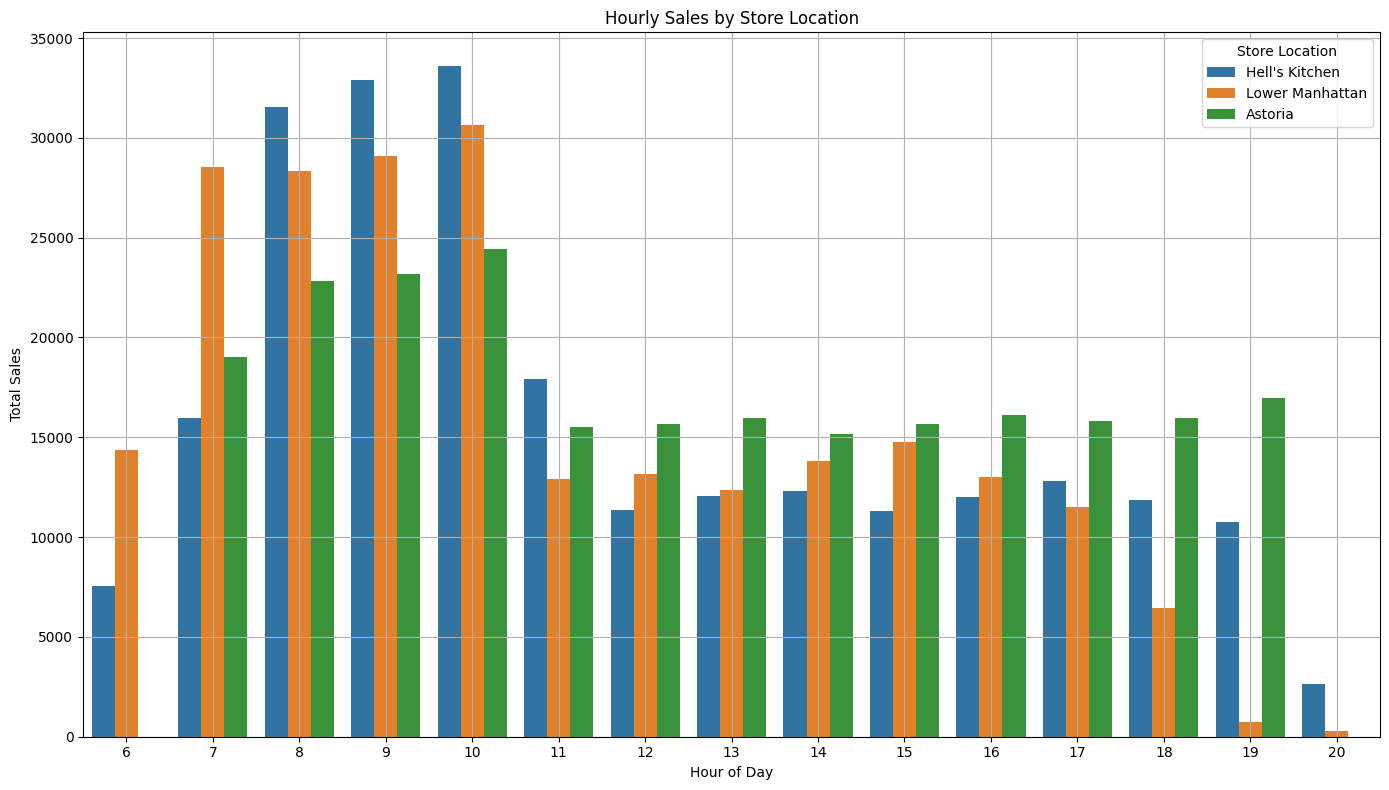

In [57]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=hourly_sales_by_location,
    x='hour',
    y='sales',
    hue='store_location'
)

# Tambahkan label dan judul
plt.title('Hourly Sales by Store Location')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales')
plt.legend(title='Store Location', loc='upper right')
plt.grid(True)

# Tampilkan plot
plt.tight_layout()
plt.show()